# CP5 · Notebook 07 — Reward shaping y reward hacking

Modificamos la recompensa para incentivar **comfort** (no cambiar carril sin necesidad), re-entrenamos 10k timesteps, y vemos cómo cambia el comportamiento. ~8 min.

In [1]:
import json, time, numpy as np
from pathlib import Path
import gymnasium as gym
import highway_env
from gymnasium.wrappers import FlattenObservation
from stable_baselines3 import DQN
import matplotlib.pyplot as plt

OUT = Path('../outputs')
MODELS = Path('../models')

objc[34185]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.2/lib/libSDL2-2.0.0.dylib (0x1105ecbf8) and /private/tmp/claude-501/-Users-erlantzmarcos-Projects-AIC/99882926-c5dd-4419-9d4b-4d9562471efd/scratchpad/venv-cp5/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110aec9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[34185]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.2/lib/libSDL2-2.0.0.dylib (0x1105ecc48) and /private/tmp/claude-501/-Users-erlantzmarcos-Projects-AIC/99882926-c5dd-4419-9d4b-4d9562471efd/scratchpad/venv-cp5/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110aeca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[34185]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.2/lib/libSDL2-2.0.0.dylib 

## 1. Wrapper que modifica la recompensa

Añadimos una **penalización por cambio de carril** (acciones 0 LANE_LEFT, 2 LANE_RIGHT).

In [2]:
LANE_CHANGE_PENALTY = 0.15   # restamos esto al reward cuando la acción es cambio de carril

class ComfortReward(gym.Wrapper):
    def step(self, action):
        obs, r, done, trunc, info = self.env.step(action)
        if action in (0, 2):    # LANE_LEFT, LANE_RIGHT
            r -= LANE_CHANGE_PENALTY
            info['comfort_penalty'] = LANE_CHANGE_PENALTY
        return obs, r, done, trunc, info

def make_env_shaped(seed=0):
    env = gym.make('highway-v0', config={
        'observation': {'type': 'Kinematics', 'vehicles_count': 5,
                         'features': ['presence','x','y','vx','vy'], 'normalize': True},
        'action': {'type': 'DiscreteMetaAction'},
        'lanes_count': 4, 'vehicles_count': 20, 'duration': 40,
        'policy_frequency': 5,
    })
    env = ComfortReward(env)
    env = FlattenObservation(env)
    return env

## 2. Fine-tune desde el DQN entrenado en 05

In [3]:
env_shaped = make_env_shaped()

# Cargar modelo previo + asociar nuevo entorno
model_shaped = DQN.load(MODELS / 'dqn_highway.zip', env=env_shaped)
model_shaped.exploration_initial_eps = 0.3   # algo más de exploración para adaptarse al nuevo reward
model_shaped.exploration_final_eps = 0.05
print('DQN cargado, lo fine-tuneamos con la nueva recompensa')

FINETUNE_STEPS = 10_000
t0 = time.time()
model_shaped.learn(total_timesteps=FINETUNE_STEPS, reset_num_timesteps=True, progress_bar=True)
elapsed = time.time() - t0
print(f'\nFine-tune completado en {elapsed:.0f}s')
model_shaped.save(MODELS / 'dqn_highway_comfort.zip')

Output()

DQN cargado, lo fine-tuneamos con la nueva recompensa



Fine-tune completado en 109s


## 3. Evaluar ambos modelos sobre el ENTORNO ORIGINAL (sin penalty)

**Importante**: evaluamos sobre el **entorno original** para comparar de manera justa.

Medimos también el **número de cambios de carril** — para ver si el shaping cambió comportamiento.

In [4]:
def make_env_orig(seed=0):
    env = gym.make('highway-v0', config={
        'observation': {'type': 'Kinematics', 'vehicles_count': 5,
                         'features': ['presence','x','y','vx','vy'], 'normalize': True},
        'action': {'type': 'DiscreteMetaAction'},
        'lanes_count': 4, 'vehicles_count': 20, 'duration': 40,
        'policy_frequency': 5,
    })
    return FlattenObservation(env)

def evaluate_model(model, n_eval=30, seed_base=20000):
    returns, lane_changes, crashes = [], [], []
    for ep in range(n_eval):
        env = make_env_orig()
        obs, info = env.reset(seed=seed_base + ep)
        ep_return, lc, crashed = 0.0, 0, False
        while True:
            action, _ = model.predict(obs, deterministic=True)
            a_int = int(action)
            if a_int in (0, 2): lc += 1
            obs, r, done, trunc, info = env.step(a_int)
            ep_return += r
            if done or trunc:
                crashed = info.get('crashed', False); break
        env.close()
        returns.append(ep_return); lane_changes.append(lc); crashes.append(crashed)
    return {
        'mean_return': float(np.mean(returns)),
        'std_return':  float(np.std(returns)),
        'mean_lane_changes': float(np.mean(lane_changes)),
        'crash_rate': float(sum(crashes) / n_eval),
    }

model_orig = DQN.load(MODELS / 'dqn_highway.zip')
orig_stats = evaluate_model(model_orig)
shaped_stats = evaluate_model(model_shaped)

print(f'{"métrica":<25s} {"original":>12s} {"shaped (comfort)":>17s}')
print('-' * 60)
print(f'{"mean return":<25s} {orig_stats["mean_return"]:>12.2f} {shaped_stats["mean_return"]:>17.2f}')
print(f'{"mean lane changes":<25s} {orig_stats["mean_lane_changes"]:>12.1f} {shaped_stats["mean_lane_changes"]:>17.1f}')
print(f'{"crash rate":<25s} {100*orig_stats["crash_rate"]:>11.0f}% {100*shaped_stats["crash_rate"]:>16.0f}%')

métrica                       original  shaped (comfort)
------------------------------------------------------------
mean return                      89.52             63.81
mean lane changes                 46.9               4.0
crash rate                         90%              100%


## 4. Análisis del comportamiento

**Lo que deberías ver**:
- `lane changes` **bajan** sensiblemente con la nueva recompensa.
- `return` original **probablemente baja** un poco (porque pierde flexibilidad).
- `crash rate` puede **subir** si el agente evita cambiar carril cuando hay tráfico — **eso es reward hacking incipiente**.

**Reward hacking en este caso**: el agente prefiere chocar (evento puntual) que la pena acumulada de cambiar de carril muchas veces. ¿Es lo que queremos? Casi seguro no.

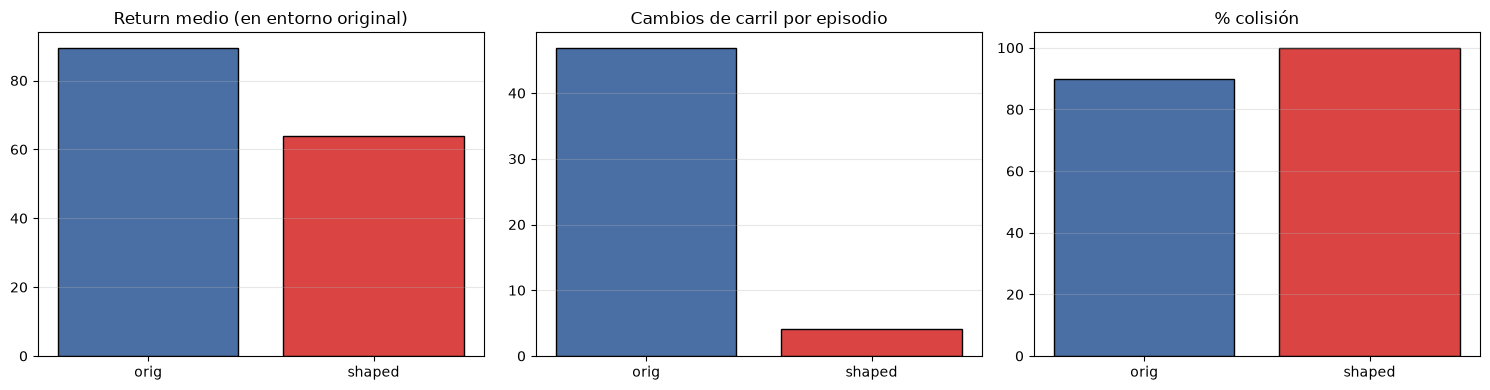

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['orig', 'shaped']
colors = ['#4a6fa5', '#DA4544']
axes[0].bar(labels, [orig_stats['mean_return'], shaped_stats['mean_return']], color=colors, edgecolor='black')
axes[0].set_title('Return medio (en entorno original)'); axes[0].grid(axis='y', alpha=0.3)
axes[1].bar(labels, [orig_stats['mean_lane_changes'], shaped_stats['mean_lane_changes']], color=colors, edgecolor='black')
axes[1].set_title('Cambios de carril por episodio'); axes[1].grid(axis='y', alpha=0.3)
axes[2].bar(labels, [100*orig_stats['crash_rate'], 100*shaped_stats['crash_rate']], color=colors, edgecolor='black')
axes[2].set_title('% colisión'); axes[2].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(OUT / '07_shaping_compare.png', dpi=100, bbox_inches='tight'); plt.show()

with open(OUT / '07_shaping_summary.json', 'w') as f:
    json.dump({
        'comfort_penalty': LANE_CHANGE_PENALTY,
        'finetune_timesteps': FINETUNE_STEPS,
        'original': orig_stats,
        'shaped': shaped_stats,
    }, f, indent=2)

## 5. Discusión: ¿qué reward hacking has visto?

Apunta para `08_preguntas.md`:

1. ¿El número de cambios de carril bajó? ¿Cuánto?
2. ¿El % de colisión subió? Si sí, **el agente prefiere chocar a cambiar de carril repetidamente** — clásico reward hacking.
3. ¿Qué cambiarías de la recompensa para mitigarlo?
   - Más peso a la colisión (penalty más grande).
   - Penalty por colisión proporcional a velocidad.
   - Bonus por mantener distancia mínima.
   - Limitar lane changes consecutivos en lugar de penalizar todos.

Esto es el **arte real del RL** — diseñar reward functions que produzcan el comportamiento deseado **sin agujeros**.

Ve a `08_preguntas.md`.